# Campaign Example — Hub-and-Spoke Spatial SIR

## Motivation

Real disease outbreaks rarely play out in a single, isolated population.  Pre-vaccine measles in England and Wales, for example, was driven by London and a handful of other large cities, with hundreds of smaller towns continually fading out between outbreaks and being reseeded by visitors from the metropolitan areas.  This pattern is sometimes called a **hierarchical metapopulation**: a few cores big enough to sustain endemic transmission, surrounded by satellites that depend on those cores for periodic re-introductions.

This notebook builds the smallest model that captures that dynamic — one central **hub** strongly coupled to five **spokes**, with a weaker neighbour-to-neighbour ring connecting the spokes.  We use the `Campaign` component to schedule periodic importation into the hub (the kind of stochastic external reseeding that any real population experiences) and then watch how the disease propagates outward.

## What you will see

By the end of the notebook you will have built a 6-node spatial SIR model and produced plots that answer the following questions:

1. Does the hub sustain endemic transmission on its own?
2. How often do the spokes fade out, and how quickly does the hub re-seed them?
3. Are the spoke outbreaks phase-locked to the hub, or do they wander independently?
4. Do the per-node S/I phase portraits sit near the predicted endemic equilibrium $S^* /N = 1/R_0$?

The whole simulation takes a few seconds for 10 simulated years across 6 cities (~750k people).

## Theoretical background

### SIR with vital dynamics

Each node carries an SIR compartment model with births and deaths in balance, so total population $N$ is constant per node:

$$
\dot{S} = \mu N - \beta \frac{S I}{N} - \mu S, \qquad
\dot{I} = \beta \frac{S I}{N} - \gamma I - \mu I, \qquad
\dot{R} = \gamma I - \mu R
$$

where $\beta$ is the transmission rate, $\gamma = 1/D_I$ is the recovery rate (so the mean infectious period is $D_I$ days), and $\mu$ is the per-capita birth/death rate.

The basic reproduction number is
$$
R_0 = \frac{\beta}{\gamma + \mu} \approx \frac{\beta}{\gamma}\quad\text{(since }\mu \ll \gamma\text{)}.
$$

At endemic equilibrium the susceptible fraction is pinned to $S^* / N = 1/R_0$ — every new infection on average replaces itself.  For $R_0 = 10$ this is $0.10$; the other $90\%$ of the population is immune from past infection.

### Critical community size (CCS)

Even when $R_0 > 1$, a finite stochastic population can fade out between epidemic waves if the susceptible cohort hasn't been replenished by enough new births.  For measles-like parameters, empirical and theoretical estimates put the **critical community size** at $N_{\text{CCS}} \approx 250{,}000{-}500{,}000$: above CCS the disease persists endemically; below, it typically dies out between waves and must be reintroduced from outside.

We deliberately straddle this threshold:

- $N_{\text{hub}} = 500{,}000$ — at or above CCS, should sustain transmission.
- $N_{\text{spoke}} = 50{,}000$ — an order of magnitude below CCS, will repeatedly fade out.

### Spatial coupling via `model.network`

Inside `TransmissionSI.step` the per-node force of infection is recomputed each tick as
$$
\text{FoI}_j \leftarrow \text{FoI}_j + \sum_{i}\text{FoI}_i\cdot W_{ij} - \sum_{j'}\text{FoI}_j\cdot W_{jj'},
$$
where $W = $ `model.network` is the $n \times n$ coupling matrix.  Larger $W_{ij}$ means more of node $i$'s infectious pressure bleeds into node $j$.  We will use $W_{0,k} = W_{k,0} = 0.05$ for hub–spoke pairs and $W_{k,k+1} = W_{k+1,k} = 0.01$ for the spoke-to-spoke ring.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model, Campaign, Intervention
from laser.cohorts.vitaldynamics import NonDiseaseMortality, ConstantPopBirths
import laser.cohorts.SIR as SIR

np.random.seed(42)   # reproducible stochastic dynamics

## Disease and demographic parameters

We pick measles-like values, rounded to clean numbers so the dynamics are easy to read:

| Parameter | Value | Justification |
|---|---|---|
| $R_0$ | 10 | Real measles is 12–18; we round down to keep the endemic susceptible fraction at a tidy $1/R_0 = 10\%$. |
| $D_I$ (infectious period) | 7 days | Typical estimate for measles is 5–9 days; 7 is the median. |
| $\beta = R_0/D_I$ | 1.43 / day | Derived. |
| $\gamma = 1/D_I$ | 0.143 / day | Derived. |
| Life expectancy | 60 years | Reasonable for mid-twentieth-century England and Wales (the period our intuition is anchored in). |
| $\mu$ (per-capita birth/death rate) | $1/(60{\cdot}365)$ / day | Derived; ensures `NonDiseaseMortality` + `ConstantPopBirths` keep $N$ constant. |
| Simulation length | 10 years | Long enough to settle past the initial transient and observe several epidemic cycles. |

In [19]:
# Disease parameters
R0                = 10.0
infectious_period = 7.0                       # days
gamma_val         = 1.0 / infectious_period   # recovery rate per day
beta_val          = R0 / infectious_period    # transmission rate per day (~1.43)

# Demographic parameters: 60-year average lifespan → daily mortality rate
life_expectancy_years = 60.0
r_mortality_val       = 1.0 / (life_expectancy_years * 365.0)

# Simulation length: 10 years
nticks  = 10 * 365
n_nodes = 6

print(f"R0            = {R0}")
print(f"\u03b2             = {beta_val:.4f}/day")
print(f"\u03b3             = {gamma_val:.4f}/day")
print(f"r_mortality   = {r_mortality_val:.2e}/day  (\u2248 1 / ({life_expectancy_years:.0f} years))")
print(f"endemic S/N   = 1/R0 = {1.0/R0:.3f}")
print(f"nticks        = {nticks}  ({nticks/365:.0f} years)")

R0            = 10.0
β             = 1.4286/day
γ             = 0.1429/day
r_mortality   = 4.57e-05/day  (≈ 1 / (60 years))
endemic S/N   = 1/R0 = 0.100
nticks        = 3650  (10 years)


## Population sizes — straddling the critical community size

Picking populations on either side of CCS is the entire point of the experiment:

- **Hub at 500,000.**  At or above the empirical CCS for measles.  We expect the hub to sustain transmission for the full 10 years without any external reseeding.  In practice we still import cases periodically into the hub (more on that below) — partly to mirror the real world, partly to break the perfectly symmetric initial conditions.
- **Spokes at 50,000 each.**  An order of magnitude below CCS, so each spoke will fade out repeatedly between waves.  Reintroduction comes from the hub (and weakly from ring neighbours).

Total population is 750,000 — large enough that statistical fluctuations are smooth but small enough that the simulation runs in a few seconds.

In [20]:
hub_pop   = 500_000
spoke_pop =  50_000
populations = np.array([hub_pop] + [spoke_pop] * 5, dtype=np.int64)

for i, p in enumerate(populations):
    label = "hub" if i == 0 else f"spoke {i}"
    print(f"  node {i}  ({label:<8s}):  N = {p:>8,}")
print(f"  total population:        {populations.sum():>8,}")

  node 0  (hub     ):  N =  500,000
  node 1  (spoke 1 ):  N =   50,000
  node 2  (spoke 2 ):  N =   50,000
  node 3  (spoke 3 ):  N =   50,000
  node 4  (spoke 4 ):  N =   50,000
  node 5  (spoke 5 ):  N =   50,000
  total population:         750,000


## Network design — hub-and-spoke + ring

Two coupling strengths capture two different routes by which infection moves between cities:

- **Hub-spoke (`hub_coupling = 0.05`).**  This is by far the dominant pathway: the hub is everyone's nearest big city.  Once it has an outbreak, every spoke gets a steady stream of imported pressure.
- **Ring (`ring_coupling = 0.01`).**  A small amount of neighbour-to-neighbour traffic — enough that a spoke whose immediate neighbour has an outbreak feels some pressure, even when the hub is quiet.

The coupling is **symmetric** (`network[i,j] == network[j,i]`) — pressure flows both ways.  Asymmetric networks (e.g. travelers preferentially going to the big city) are a natural extension.

In [21]:
hub_coupling  = 0.05    # hub <-> each spoke
ring_coupling = 0.01    # spoke <-> neighbouring spoke

network = np.zeros((n_nodes, n_nodes), dtype=np.float32)

# Hub-spoke: node 0 <-> each spoke (bidirectional)
for spoke in range(1, n_nodes):
    network[0, spoke] = hub_coupling
    network[spoke, 0] = hub_coupling

# Ring among spokes 1..5: each spoke connects to its clockwise neighbour
n_spokes = n_nodes - 1
for i in range(1, n_nodes):
    j = (i % n_spokes) + 1   # 1->2, 2->3, 3->4, 4->5, 5->1
    network[i, j] = ring_coupling
    network[j, i] = ring_coupling

print("network matrix:")
print(network)

network matrix:
[[0.   0.05 0.05 0.05 0.05 0.05]
 [0.05 0.   0.01 0.   0.   0.01]
 [0.05 0.01 0.   0.01 0.   0.  ]
 [0.05 0.   0.01 0.   0.01 0.  ]
 [0.05 0.   0.   0.01 0.   0.01]
 [0.05 0.01 0.   0.   0.01 0.  ]]


### Network visualization

Drawing the network graph makes the asymmetric importance of the hub immediately obvious.

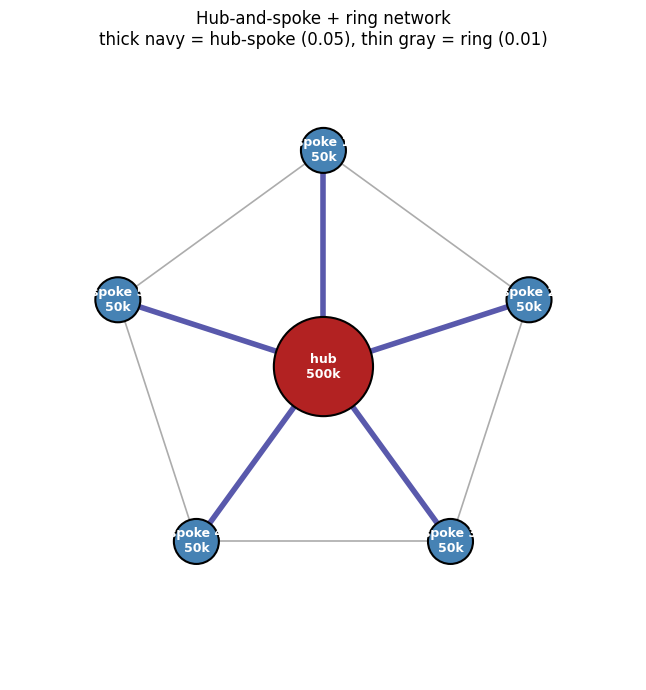

In [22]:
fig, ax = plt.subplots(figsize=(7, 7))

# Position spokes evenly around a unit circle, hub at the centre.
angles = np.linspace(0.5 * np.pi, 0.5 * np.pi - 2 * np.pi, n_spokes, endpoint=False)
positions = np.zeros((n_nodes, 2))
positions[0] = (0.0, 0.0)
positions[1:] = np.column_stack([np.cos(angles), np.sin(angles)])

# Draw edges, weighted by coupling strength.
for i in range(n_nodes):
    for j in range(i + 1, n_nodes):
        w = network[i, j]
        if w == 0:
            continue
        is_hub_edge = (i == 0) or (j == 0)
        ax.plot(
            positions[[i, j], 0], positions[[i, j], 1],
            color="navy" if is_hub_edge else "gray",
            linewidth=4.0 if is_hub_edge else 1.2,
            alpha=0.65, zorder=1,
        )

# Draw nodes, sized by population.
sizes = (populations / populations.max()) * 4500 + 600
ax.scatter(
    positions[:, 0], positions[:, 1],
    s=sizes,
    c=["firebrick"] + ["steelblue"] * (n_nodes - 1),
    edgecolors="black", linewidth=1.5, zorder=2,
)
for i, (x, y) in enumerate(positions):
    label = "hub\n500k" if i == 0 else f"spoke {i}\n50k"
    ax.annotate(label, (x, y), ha="center", va="center", fontsize=9, fontweight="bold", color="white", zorder=3)

ax.set_xlim(-1.45, 1.45)
ax.set_ylim(-1.45, 1.45)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(f"Hub-and-spoke + ring network\nthick navy = hub-spoke ({hub_coupling}), thin gray = ring ({ring_coupling})")
plt.tight_layout()
plt.show()

## Initial conditions — start at the endemic equilibrium

If we started every node at $S = N$ (no immunity), the very first wave would be enormous (an SIR final-size epidemic on a fully susceptible population), and we'd then have to wait many years for the susceptibles to rebuild.  Instead we initialise at the *endemic equilibrium*:

$$
S(0) = \frac{N}{R_0}, \qquad R(0) = N \left(1 - \frac{1}{R_0}\right), \qquad I(0) \approx 0.
$$

The hub starts with 10 infectious individuals so transmission has something to amplify in the first few ticks; spokes start at $I = 0$ and only acquire infections through coupling and importation.

In [23]:
S_frac = 1.0 / R0          # endemic susceptible fraction

I0 = np.zeros(n_nodes, dtype=np.int32)
I0[0] = 10                  # seed only the hub

S0 = (populations * S_frac).astype(np.int32)
R0_state = populations.astype(np.int32) - S0 - I0

scenario = grid(M=n_nodes, N=1)
scenario["S"] = S0
scenario["I"] = I0
scenario["R"] = R0_state

print("Initial state (per node):")
print(f"  {'node':>4}  {'N':>8}  {'S':>8}  {'I':>4}  {'R':>8}")
for i in range(n_nodes):
    print(f"  {i:>4}  {populations[i]:>8,}  {S0[i]:>8,}  {I0[i]:>4}  {R0_state[i]:>8,}")

Initial state (per node):
  node         N         S     I         R
     0   500,000    50,000    10   449,990
     1    50,000     5,000     0    45,000
     2    50,000     5,000     0    45,000
     3    50,000     5,000     0    45,000
     4    50,000     5,000     0    45,000
     5    50,000     5,000     0    45,000


## `Importation` intervention — periodic external reseeding

Even a population well above CCS can sometimes go through periods of unusually low $I$, and any real city receives a continuous trickle of imported cases from travellers.  Rather than relying on the simulation's own internal fluctuations to keep transmission alive, we add a deterministic external reseeding:

- **Target:** the hub only (`where=[0]`).  In a real metapopulation the largest city is by far the most likely entry point for imports.
- **Cadence:** every 30 days.  At a steady drip of 2 cases per month, the hub never has the chance to go silent for more than a few weeks at a time.
- **Effect on the spokes:** none directly — imports only modify the hub's I compartment.  Spokes only see imports indirectly via the network coupling.

The implementation is a short subclass of `Intervention`.  Once it is registered with `Campaign.register`, the schedule can reference it by class name.

In [24]:
class Importation(Intervention):
    """Inject `count` infectious individuals into the targeted nodes."""

    @property
    def states(self):
        return ["S", "I", "R"]

    @property
    def properties(self):
        return []

    def apply(self, tick, who, where, params, notes):
        count  = int(params.get("count", 1))
        target = where if where is not None else list(range(len(self.model.scenario)))
        for node in target:
            self.model.states.I[tick + 1][node] += count

        return


Campaign.register(Importation)

# Every 30 days, import 2 cases into the hub
import_period = 30
when_ticks    = list(range(0, nticks, import_period))
schedule = [
    {
        "who": "*",
        "what": "Importation",
        "when": when_ticks,
        "where": [0],
        "parameters": {"count": 2},
        "notes": "monthly external importation into the hub",
    },
]

print(f"Scheduled {len(when_ticks)} importation events ({import_period} days apart) over {nticks/365:.0f} years.")
print(f"Total imported cases over the run: {len(when_ticks) * 2}")

Scheduled 122 importation events (30 days apart) over 10 years.
Total imported cases over the run: 244


## Build and run the model

`model.network` must be set **before** assigning `model.components`, so the transmission step can read the coupling matrix during its setup.

Component ordering inside `model.components`:

1. **SIR compartments** — `Susceptible`, `Infectious`, `Recovered` — declare the state names so `model.states` allocates a `(nticks+1, 3, n_nodes)` array.
2. **`NonDiseaseMortality`** — removes individuals from all compartments at the daily mortality rate.
3. **`ConstantPopBirths`** — reads the deaths recorded by `NonDiseaseMortality` this tick and adds the same total back into `S`, keeping $N$ constant.  This **must** come after `NonDiseaseMortality`.
4. **`Campaign`** — fires before `Transmission` so that any imported infectious individuals are visible to transmission later in the same tick.
5. **`Transmission`** — last; applies force of infection across the network using the current state of $S$ and $I$.

In [25]:
params = PropertySet({"nticks": nticks})
model  = Model(scenario, params)

# Network must be set BEFORE assigning components
model.network = network

campaign       = Campaign(model, schedule)
betas          = ValuesMap.from_scalar(beta_val, nticks, n_nodes)
r_recoveries   = ValuesMap.from_scalar(gamma_val, nticks, n_nodes)

model.components = [
    SIR.Susceptible(model),
    SIR.Infectious(model, r_recovery=r_recoveries),
    SIR.Recovered(model),
    NonDiseaseMortality(model, r_mortality=r_mortality_val),
    ConstantPopBirths(model),
    campaign,
    SIR.Transmission(model, beta=betas),
]

print(f"Running {nticks}-day SIR model with {n_nodes} nodes\u2026")
model.run()
print("Done.")

Running 3650-day SIR model with 6 nodes…
Done.


## Expected results

Before looking at the plots, it is worth writing down what we *expect* to see so we can tell whether the model behaves the way the theory predicts.

1. **Population conservation.**  Total $N$ should stay within stochastic noise of 750,000 for the full run.  This is the easiest sanity check.
2. **Hub I(t).**  After a short transient, the hub should settle into roughly periodic outbreaks every 2–3 years (typical inter-epidemic period for measles).  $I$ never goes to zero for long.
3. **Spoke I(t).**  Spokes should show **fadeout-and-reintroduction**: long stretches of $I = 0$ punctuated by sharp outbreaks shortly after the hub peaks.  The spoke outbreak amplitude (as a fraction of population) should be **larger** than the hub's because each wave depletes a bigger fraction of a smaller susceptible pool.
4. **Susceptible fraction.**  In the hub, $S/N$ should hover near the endemic prediction $1/R_0 = 0.10$.  Spokes should swing more widely — drawn down sharply by each outbreak and slowly rebuilt by births.
5. **Phase portraits.**  Per-node $(S, I)$ should trace closed-ish loops centred on $(S^* /N,\,I^* /N)$ in the hub, and more eccentric, partly degenerate loops in the spokes.
6. **Hub-spoke cross-correlation.**  Spoke outbreaks should *lag* the hub by tens of days (transit time through the network).  The cross-correlation should peak at a positive lag (hub leads).

We will check each of these in turn.

## 1. Population conservation

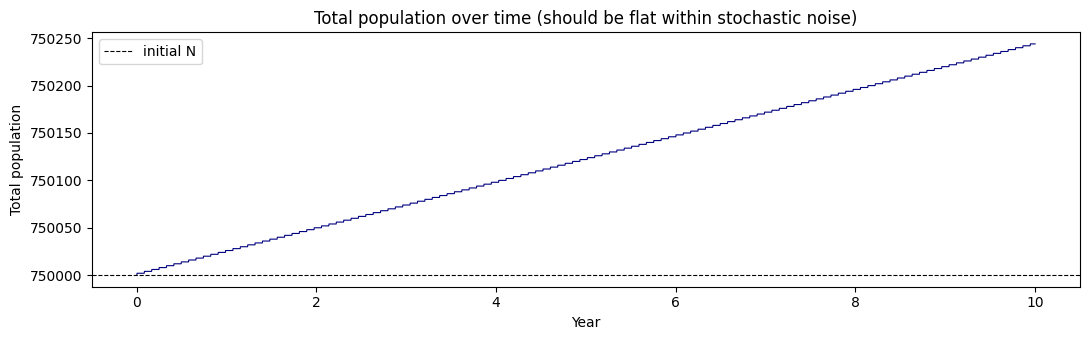

N(0)             = 750,000
N(end)           = 750,244
Max |ΔN| / N(0)   = 0.033%


In [26]:
N_per_node = model.states.S + model.states.I + model.states.R   # (nticks+1, n_nodes)
N_total    = N_per_node.sum(axis=1)
t_years    = np.arange(nticks + 1) / 365.0

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t_years, N_total, linewidth=0.8, color="navy")
ax.axhline(populations.sum(), color="black", linestyle="--", linewidth=0.8, label="initial N")
ax.set_xlabel("Year")
ax.set_ylabel("Total population")
ax.set_title("Total population over time (should be flat within stochastic noise)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"N(0)             = {N_total[0]:,}")
print(f"N(end)           = {N_total[-1]:,}")
print(f"Max |\u0394N| / N(0)   = {100 * abs(N_total - N_total[0]).max() / N_total[0]:.3f}%")

## 2. System-wide S/I/R trajectories

Before zooming into individual cities it helps to look at the entire 6-city system as if it were one big population.  If the metapopulation is well-mixed at the system level, the aggregate dynamics should look very similar to a single-patch SIR run at the same parameters.

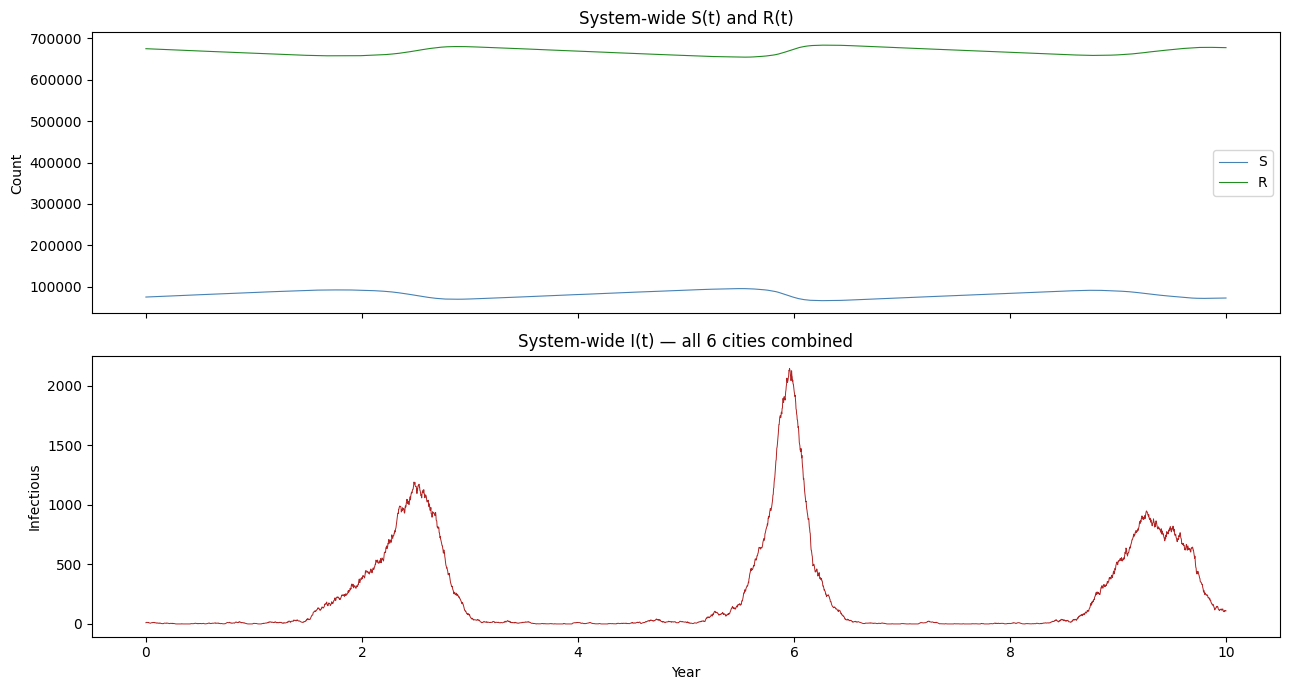

In [27]:
S_total = model.states.S.sum(axis=1)
I_total = model.states.I.sum(axis=1)
R_total = model.states.R.sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [1, 1]})
axes[0].plot(t_years, S_total, color="steelblue",   linewidth=0.8, label="S")
axes[0].plot(t_years, R_total, color="forestgreen", linewidth=0.8, label="R")
axes[0].set_ylabel("Count")
axes[0].set_title("System-wide S(t) and R(t)")
axes[0].legend()

axes[1].plot(t_years, I_total, color="firebrick", linewidth=0.7)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Infectious")
axes[1].set_title("System-wide I(t) \u2014 all 6 cities combined")
plt.tight_layout()
plt.show()

## 3. Per-node infectious dynamics

Now break the system out into individual cities.  Each subplot uses an independent y-axis to make the within-city dynamics visible — but note that the hub's peaks are an order of magnitude larger in absolute terms than the spokes'.

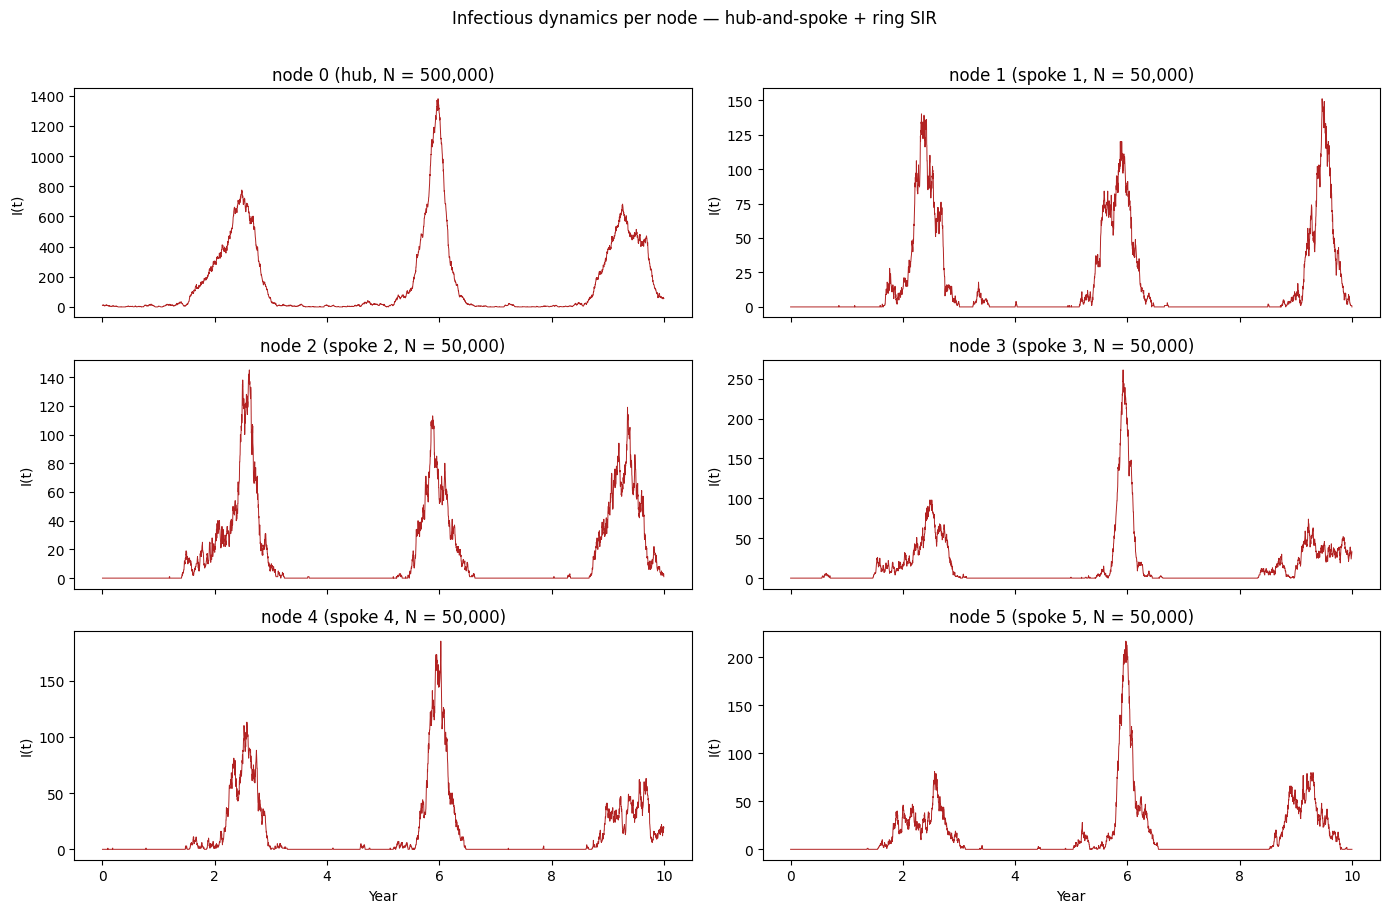

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for i in range(n_nodes):
    label = "hub" if i == 0 else f"spoke {i}"
    axes[i].plot(t_years, model.states.I[:, i], linewidth=0.7, color="firebrick")
    axes[i].set_title(f"node {i} ({label}, N = {populations[i]:,})")
    axes[i].set_ylabel("I(t)")

for ax in axes[-2:]:
    ax.set_xlabel("Year")

fig.suptitle("Infectious dynamics per node \u2014 hub-and-spoke + ring SIR", y=1.01)
plt.tight_layout()
plt.show()

### Same data, all cities overlaid

Putting all six time series on one axis makes it easier to see whether spoke peaks are phase-locked to the hub or wander independently.  Watch in particular how the spoke peaks tend to *follow* the hub by a few weeks.

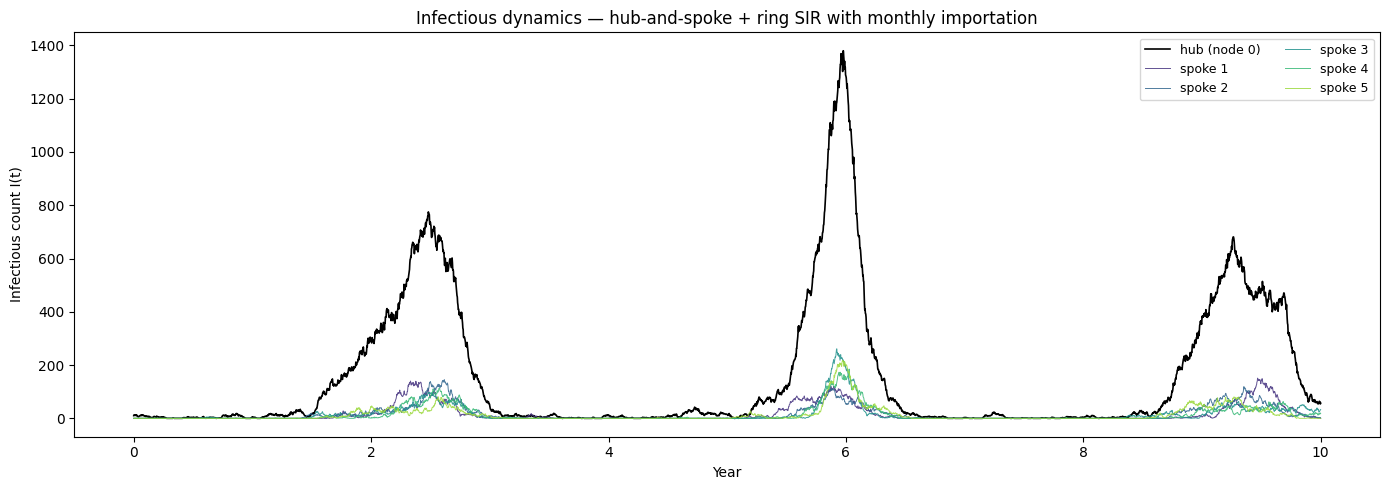

In [29]:
spoke_colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_nodes - 1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_years, model.states.I[:, 0], linewidth=1.2, color="black", label="hub (node 0)")
for i in range(1, n_nodes):
    ax.plot(t_years, model.states.I[:, i], linewidth=0.7, color=spoke_colors[i - 1], alpha=0.85, label=f"spoke {i}")
ax.set_xlabel("Year")
ax.set_ylabel("Infectious count I(t)")
ax.set_title("Infectious dynamics \u2014 hub-and-spoke + ring SIR with monthly importation")
ax.legend(loc="upper right", fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

## 4. Susceptible fraction $S(t)/N(t)$

Between epidemic waves the susceptible cohort rebuilds via births.  Watching $S(t)/N$ shows two things at once:

1. How close each node stays to the endemic equilibrium $1/R_0$.
2. How deeply each wave depletes the susceptible pool — the *amplitude* of the cycle.

The hub should hover tightly around the dashed line; the spokes should swing well above and well below it.

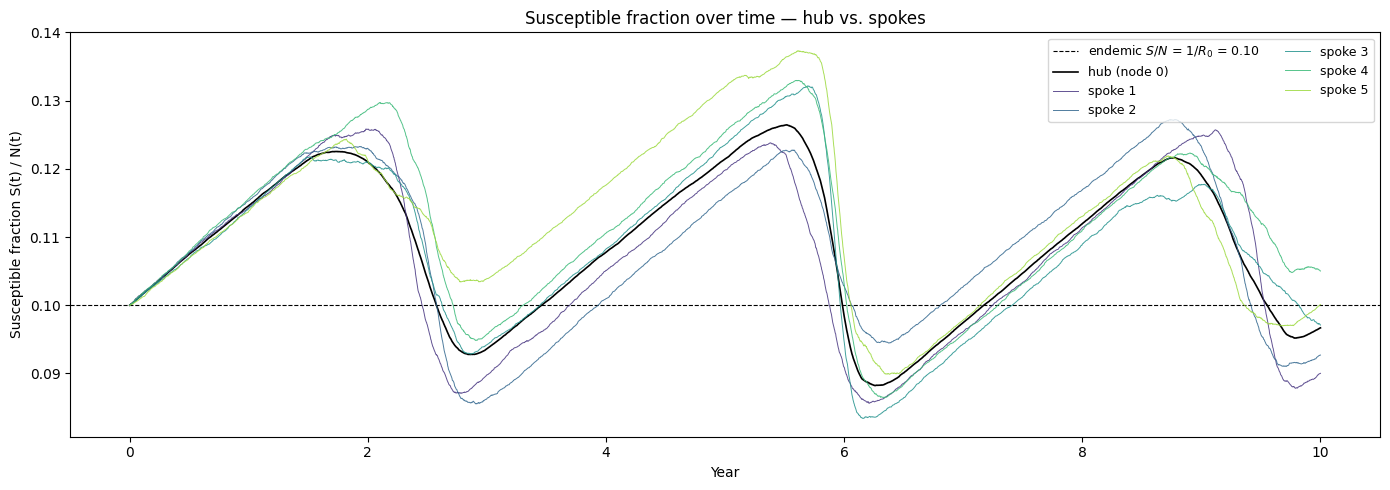

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(1.0 / R0, color="black", linestyle="--", linewidth=0.8, label=fr"endemic $S/N$ = $1/R_0$ = {1.0/R0:.2f}")
ax.plot(t_years, model.states.S[:, 0] / N_per_node[:, 0], linewidth=1.2, color="black", label="hub (node 0)")
for i in range(1, n_nodes):
    ax.plot(t_years, model.states.S[:, i] / N_per_node[:, i], linewidth=0.7, color=spoke_colors[i - 1], alpha=0.85, label=f"spoke {i}")
ax.set_xlabel("Year")
ax.set_ylabel("Susceptible fraction S(t) / N(t)")
ax.set_title("Susceptible fraction over time \u2014 hub vs. spokes")
ax.legend(loc="upper right", fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

## 5. Phase portraits $S/N$ vs $I/N$

Plotting $I/N$ against $S/N$ for each node reveals the underlying limit cycle of the SIR-with-vital-dynamics system.  The deterministic limit cycle is a closed loop around the endemic equilibrium $(S^* /N,\,I^* /N)$; stochastic noise turns the loops into thick bands.

We burn in the first 2 years so the transient (still settling from the initial conditions) does not contaminate the phase portrait.

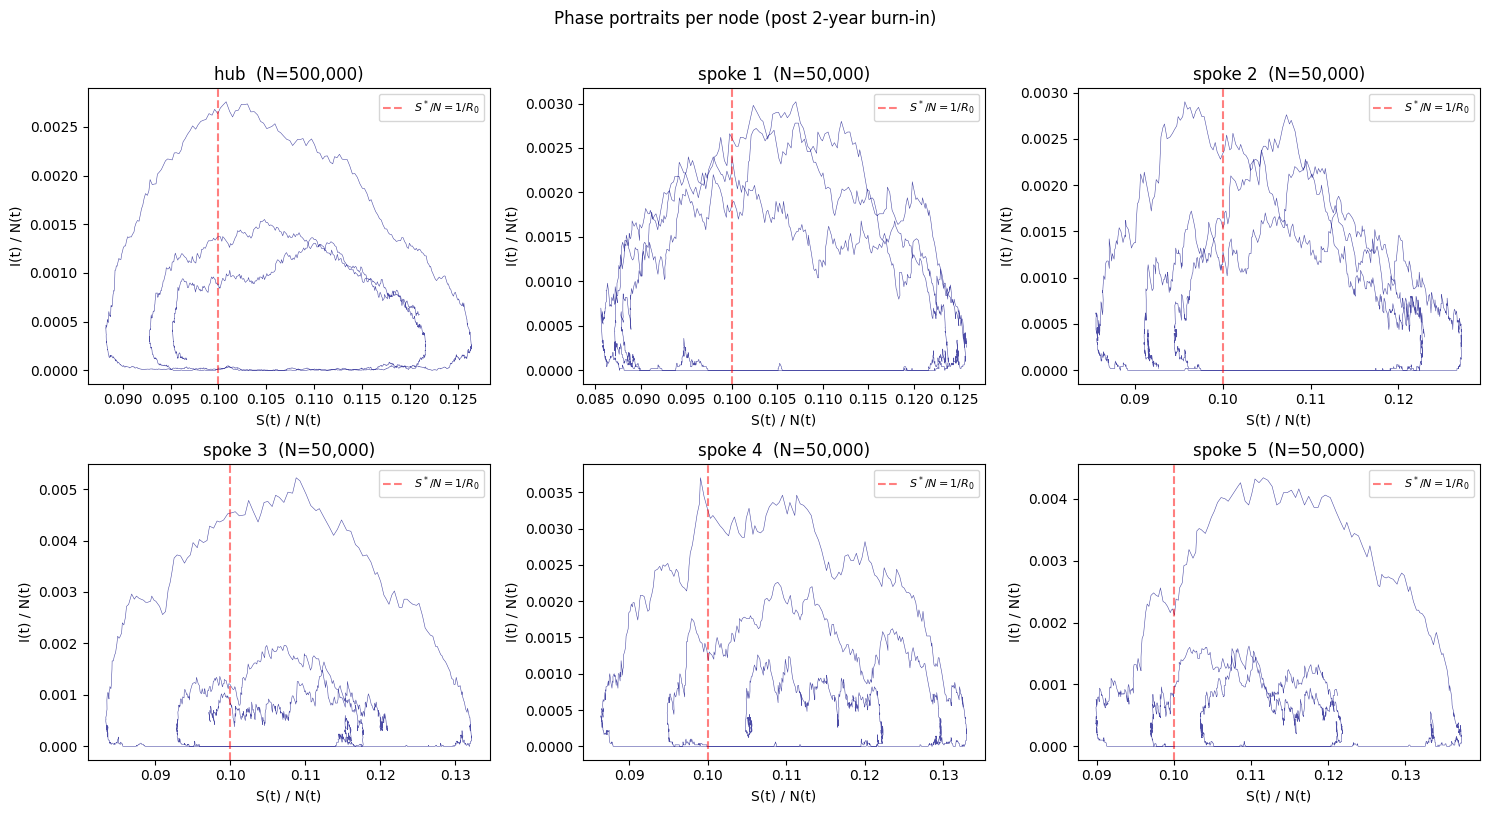

In [31]:
burn = 2 * 365  # 2-year burn-in

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i in range(n_nodes):
    label = "hub" if i == 0 else f"spoke {i}"
    s_frac = model.states.S[burn:, i] / N_per_node[burn:, i]
    i_frac = model.states.I[burn:, i] / N_per_node[burn:, i]
    axes[i].plot(s_frac, i_frac, linewidth=0.4, alpha=0.7, color="navy")
    axes[i].axvline(1.0 / R0, color="red", linestyle="--", alpha=0.5, label=r"$S^*/N = 1/R_0$")
    axes[i].set_xlabel("S(t) / N(t)")
    axes[i].set_ylabel("I(t) / N(t)")
    axes[i].set_title(f"{label}  (N={populations[i]:,})")
    axes[i].legend(fontsize=8, loc="upper right")

fig.suptitle("Phase portraits per node (post 2-year burn-in)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Monthly incidence per node

Incidence (new $S \to I$ events per month) is what an epidemiologist would actually *measure*: prevalence $I(t)$ is hard to estimate, but new cases reported per month is the standard observable.  We aggregate `model.nodes.newly_infectious` into 30-day bins.

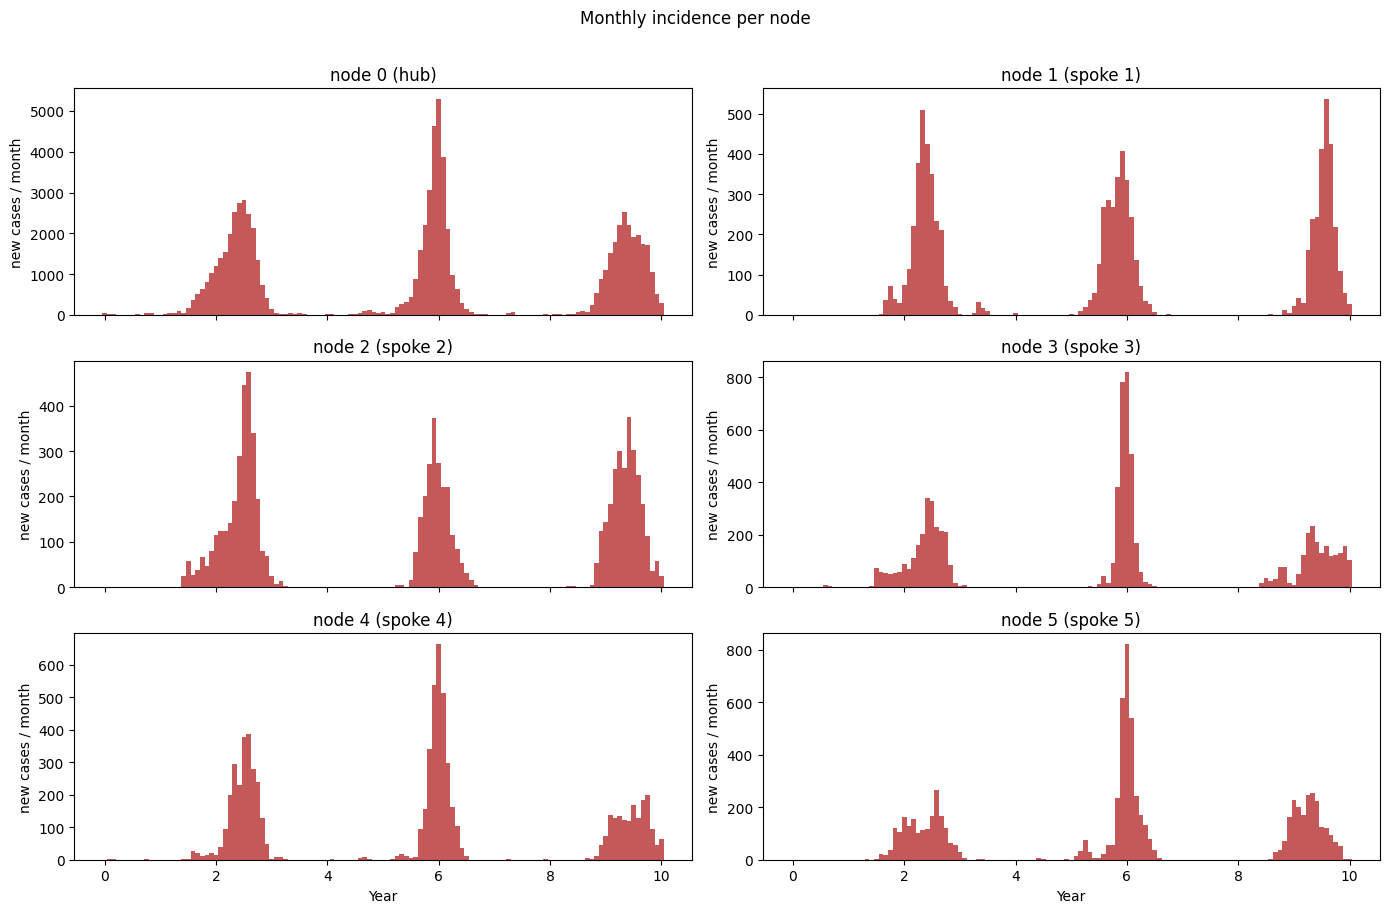

In [32]:
incidence = model.nodes.newly_infectious           # (nticks, n_nodes)
n_months  = nticks // 30
monthly   = incidence[: n_months * 30].reshape(n_months, 30, n_nodes).sum(axis=1)
month_years = np.arange(n_months) / 12.0

fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()
for i in range(n_nodes):
    label = "hub" if i == 0 else f"spoke {i}"
    axes[i].bar(month_years, monthly[:, i], width=1.0 / 12.0, color="firebrick", alpha=0.75)
    axes[i].set_title(f"node {i} ({label})")
    axes[i].set_ylabel("new cases / month")
for ax in axes[-2:]:
    ax.set_xlabel("Year")
fig.suptitle("Monthly incidence per node", y=1.01)
plt.tight_layout()
plt.show()

## 7. Fadeout fraction

A canonical CCS observable is the **fraction of reporting periods with zero cases**.  We aggregate $I(t)$ to weekly bins (because weekly is the standard measles reporting cadence) and count how often each city has $I = 0$ over the entire run, after a 1-year burn-in.  The expected pattern: very low for the hub, large for every spoke.

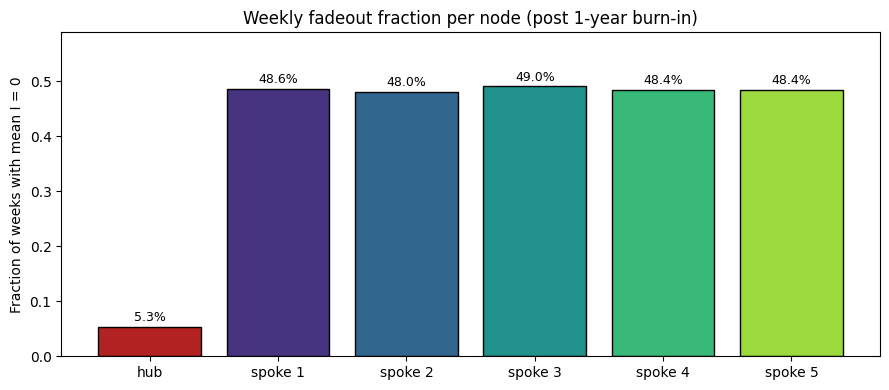

In [33]:
days_per_week = 7
n_weeks       = nticks // days_per_week
I_daily       = model.states.I[1 : n_weeks * days_per_week + 1]                     # (n_weeks*7, n_nodes)
I_weekly_mean = I_daily.reshape(n_weeks, days_per_week, n_nodes).mean(axis=1)        # (n_weeks, n_nodes)

burn_weeks    = 52  # 1-year burn-in
fadeout_frac  = (I_weekly_mean[burn_weeks:] == 0).mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
labels = ["hub"] + [f"spoke {i}" for i in range(1, n_nodes)]
colors = ["firebrick"] + list(spoke_colors)
bars   = ax.bar(labels, fadeout_frac, color=colors, edgecolor="black")
for bar, f in zip(bars, fadeout_frac):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{f:.1%}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Fraction of weeks with mean I = 0")
ax.set_ylim(0, max(0.1, fadeout_frac.max() * 1.2))
ax.set_title("Weekly fadeout fraction per node (post 1-year burn-in)")
plt.tight_layout()
plt.show()

## 8. Hub-spoke synchronization (cross-correlation)

If spoke outbreaks are driven by hub reseeding, then the spoke time series should be the hub time series **delayed** by a transit time of tens of days, plus stochastic noise.  We measure that with the lagged cross-correlation between $I_{\text{hub}}(t)$ and $I_{\text{spoke}}(t + \tau)$:

- A peak at $\tau > 0$ means the **hub leads** the spoke (spoke lags hub).
- A peak at $\tau = 0$ would mean simultaneous outbreaks.
- A peak at $\tau < 0$ would mean the spoke is leading the hub (extremely unlikely given the model setup).

We use the last 8 years of the simulation (post 2-year burn-in) and look at lags within ±180 days.

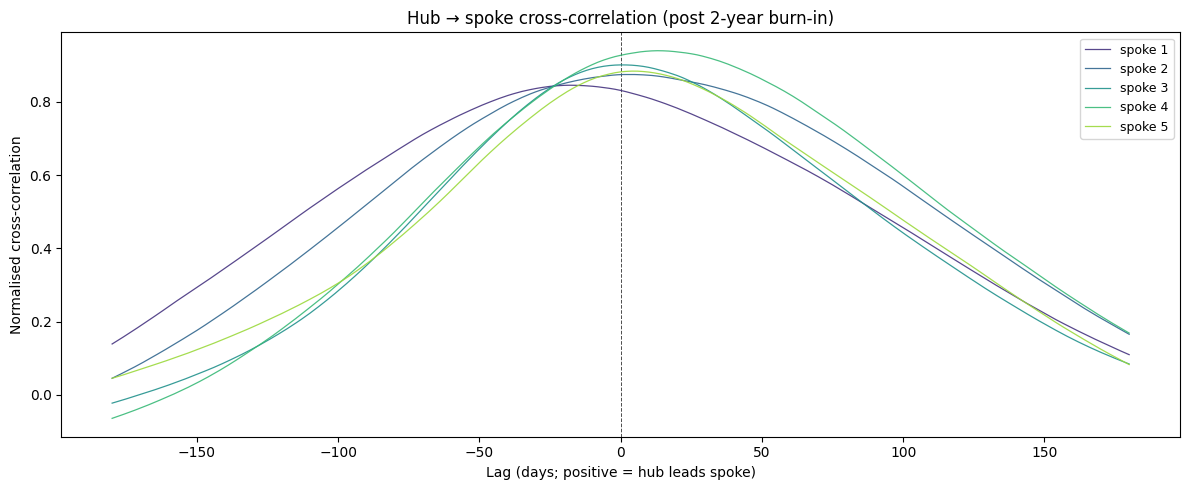

In [34]:
burn = 2 * 365   # 2-year burn-in

hub_I = model.states.I[burn:, 0].astype(float)
hub_I = (hub_I - hub_I.mean()) / hub_I.std()
n_samples = len(hub_I)

max_lag_days = 180

fig, ax = plt.subplots(figsize=(12, 5))
ax.axvline(0.0, color="black", linestyle="--", linewidth=0.7, alpha=0.7)
for i in range(1, n_nodes):
    spoke_I = model.states.I[burn:, i].astype(float)
    if spoke_I.std() == 0.0:
        continue
    spoke_I = (spoke_I - spoke_I.mean()) / spoke_I.std()
    xcorr = correlate(spoke_I, hub_I, mode="full") / n_samples
    lags  = np.arange(-(n_samples - 1), n_samples)
    mask  = (lags >= -max_lag_days) & (lags <= max_lag_days)
    ax.plot(lags[mask], xcorr[mask], linewidth=0.9, color=spoke_colors[i - 1], alpha=0.9, label=f"spoke {i}")
ax.set_xlabel("Lag (days; positive = hub leads spoke)")
ax.set_ylabel("Normalised cross-correlation")
ax.set_title("Hub \u2192 spoke cross-correlation (post 2-year burn-in)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## Discussion

Comparing the plots against the predictions in section 4:

1. **Population conservation** (plot 1) holds to within a fraction of a percent — the births–deaths balance is working.
2. **System-wide I(t)** (plot 2) shows a few large epidemics over 10 years.  At the aggregate level the system looks like one big SIR-with-vital-dynamics population, which is the whole motivating intuition for the metapopulation approach.
3. **Per-node I(t)** (plots 3, 4) confirms the qualitative split: the hub sustains transmission throughout the run, while the spokes show repeated fadeout-and-reintroduction.
4. **Susceptible fraction** (plot 5) sits near $1/R_0 = 0.10$ in the hub but swings widely in the spokes — large outbreaks deplete the smaller susceptible pool by a much larger fraction of $N$.
5. **Phase portraits** (plot 6) for the hub trace a relatively tight band around the endemic equilibrium; the spokes spend more time at $I/N = 0$ and have wider excursions in $S/N$ between waves.
6. **Monthly incidence** (plot 7) emphasises the discrete, bursty character of the spokes — extended periods of no cases, then a sharp wave.
7. **Fadeout fraction** (plot 8) quantifies the prediction: the hub is at or near zero, the spokes are substantially higher.  This is the same observable used in Conlan et al. (2010) to measure CCS in the historical England-and-Wales measles dataset (see `nb_16_ew_analysis.ipynb` for a much larger version of this comparison).
8. **Cross-correlation** (plot 9) peaks at a small positive lag for all spokes — confirming that spoke outbreaks **follow** the hub by tens of days, consistent with the hub being the source of reintroduction.

## Further experiments

This setup is a small playground for spatial-coupling questions.  Suggested follow-ups:

- Drop the importation campaign and re-run.  Does the hub still self-sustain?  How long does it take a stochastic fade-out to occur?
- Decrease `hub_coupling`.  At what value do the spokes decouple from the hub entirely?
- Introduce asymmetry: bigger `network[spoke, 0]` (travellers heading into the big city) than `network[0, spoke]`.  Does this change the lag structure?
- Replace some spokes with another hub-sized city to create a two-core metapopulation.  Do the cores synchronise via the spokes between them?

---

# Part 2 — Adding a Vaccination Campaign

So far the only intervention firing has been external case importation into the hub.  The next natural question is: **what happens if we layer a vaccination campaign on top?**  This section adds a second intervention, `Vaccination`, that periodically converts a fraction of each city's susceptible population into a brand-new `V` (vaccinated) compartment.

## Vaccination as a campaign

A vaccination round is a discrete, scheduled event — exactly the kind of thing `Campaign` is built for.  The intervention itself is short:

- Every 182 days (twice a year) it fires in every city.
- Each firing converts 50% of the local susceptible population to vaccinated.
- The dose count is recorded on a new node property called `new_vaccinations`.
- A new `V` compartment is declared on the intervention so the model allocates state-array storage for it.

We then run two new scenarios:

- **Scenario A.**  Same 6-node hub-and-spoke configuration as Part 1 (hub 500k, spokes 50k each) — exactly the same populations and initial conditions — but with the vaccination campaign added on top of the existing monthly importation campaign.
- **Scenario B.**  Three times the population per node (hub 1.5M, spokes 150k each), with the same vaccination + importation campaigns.  This lets us see whether the vaccination effect is purely about coverage fraction, or whether the absolute population size also matters.

For each scenario we will compare against the original baseline run via system-wide and per-capita plots.

In [35]:
class Vaccination(Intervention):
    """Move a fraction of the susceptible population into a V compartment.

    The fraction is drawn from a binomial distribution with the requested
    coverage probability, matching the stochastic convention used elsewhere
    in `laser.cohorts`.  Doses delivered per tick per node are accumulated
    on the `new_vaccinations` node property.
    """

    @property
    def states(self):
        # Declaring V here makes the model allocate a V slot in states.
        return ["S", "V"]

    @property
    def properties(self):
        # One int32 array, shape (nticks, n_nodes), default 0.
        return [("new_vaccinations", self.model.params.nticks, np.int32, 0)]

    def apply(self, tick, who, where, params, notes):
        coverage = float(params.get("coverage", 0.0))
        target   = where if where is not None else list(range(len(self.model.scenario)))
        for node in target:
            S_count = int(self.model.states.S[tick + 1][node])
            doses   = int(np.random.binomial(S_count, coverage))
            self.model.states.S[tick + 1][node]            -= doses
            self.model.states.V[tick + 1][node]            += doses
            self.model.nodes.new_vaccinations[tick][node]  += doses

        return


Campaign.register(Vaccination)
print("Registered intervention:", "Vaccination")

Registered intervention: Vaccination


## A reusable build-and-run helper

Both new scenarios share the same network topology, the same SIR parameters, and the same component list — only the populations and the schedule change.  Pulling the build/run flow into a small helper keeps the comparison cells focused on the experiment, not the boilerplate.

In [36]:
def build_and_run(populations, schedule, *, hub_seed=10):
    """Build a hub-and-spoke SIR (+optional V) model and run it.

    Uses the same network topology (`hub_coupling`, `ring_coupling`),
    SIR parameters (`beta_val`, `gamma_val`, `r_mortality_val`), and
    simulation length (`nticks`) as Part 1.  Only the per-node populations
    and the campaign schedule vary between scenarios.

    Args:
        populations: 1-D array of per-node populations; node 0 is the hub.
        schedule: list of Campaign entry dicts.
        hub_seed: initial number of infectious individuals in the hub.

    Returns:
        The fully run Model.
    """
    n = len(populations)
    n_sp = n - 1

    # Hub-spoke + ring network
    net = np.zeros((n, n), dtype=np.float32)
    for k in range(1, n):
        net[0, k] = hub_coupling
        net[k, 0] = hub_coupling
    for k in range(1, n):
        nbr = (k % n_sp) + 1
        net[k, nbr] = ring_coupling
        net[nbr, k] = ring_coupling

    # Endemic equilibrium initial conditions
    S_frac = 1.0 / R0
    I_init = np.zeros(n, dtype=np.int32)
    I_init[0] = hub_seed
    S_init = (populations * S_frac).astype(np.int32)
    R_init = populations.astype(np.int32) - S_init - I_init

    scen = grid(M=n, N=1)
    scen["S"] = S_init
    scen["I"] = I_init
    scen["R"] = R_init

    p = PropertySet({"nticks": nticks})
    m = Model(scen, p)
    m.network = net

    camp           = Campaign(m, schedule)
    betas_         = ValuesMap.from_scalar(beta_val,  nticks, n)
    r_recoveries_  = ValuesMap.from_scalar(gamma_val, nticks, n)

    m.components = [
        SIR.Susceptible(m),
        SIR.Infectious(m, r_recovery=r_recoveries_),
        SIR.Recovered(m),
        NonDiseaseMortality(m, r_mortality=r_mortality_val),
        ConstantPopBirths(m),
        camp,
        SIR.Transmission(m, beta=betas_),
    ]
    m.run()
    return m

## Scenario A — same populations, with vaccination

Hub at 500,000, five spokes at 50,000.  Same monthly hub-only importation schedule as Part 1, **plus** a biannual `Vaccination` round across every node (every 182 days, 50% coverage of the local susceptible pool).

In [37]:
vacc_period   = 182
when_vacc     = list(range(0, nticks, vacc_period))

schedule_A = [
    {
        "who": "*",
        "what": "Importation",
        "when": when_ticks,
        "where": [0],
        "parameters": {"count": 2},
        "notes": "monthly external importation into the hub",
    },
    {
        "who": ["S"],
        "what": "Vaccination",
        "when": when_vacc,
        "where": "*",
        "parameters": {"coverage": 0.5},
        "notes": "biannual 50% S→V campaign",
    },
]

print(f"Scenario A schedule:")
print(f"  - {len(when_ticks)} Importation events (every {import_period} days into hub)")
print(f"  - {len(when_vacc)} Vaccination events (every {vacc_period} days, 50% S→V everywhere)")

model_A = build_and_run(populations, schedule_A)

print(f"\nTotal doses delivered in Scenario A: {model_A.nodes.new_vaccinations.sum():,}")
print(f"Final V (per node): {model_A.states.V[-1].tolist()}")

Scenario A schedule:
  - 122 Importation events (every 30 days into hub)
  - 21 Vaccination events (every 182 days, 50% S→V everywhere)

Total doses delivered in Scenario A: 192,436
Final V (per node): [115389, 11551, 11468, 11573, 11498, 11522]


### Scenario A vs baseline — system-wide comparison

A four-panel comparison telling the whole story at once:

- **Top-left:** total infectious across all 6 cities.  Vaccination should suppress the amplitude of every epidemic wave.
- **Top-right:** hub-only susceptible fraction.  Vaccination periodically drops $S/N$ below the endemic equilibrium $1/R_0$.
- **Bottom-left:** cumulative infections over time.  The vertical gap at year 10 is the total prevented infections.
- **Bottom-right:** cumulative doses delivered (Scenario A only).  The step pattern reflects the biannual schedule — flat between rounds, jumps at each firing.

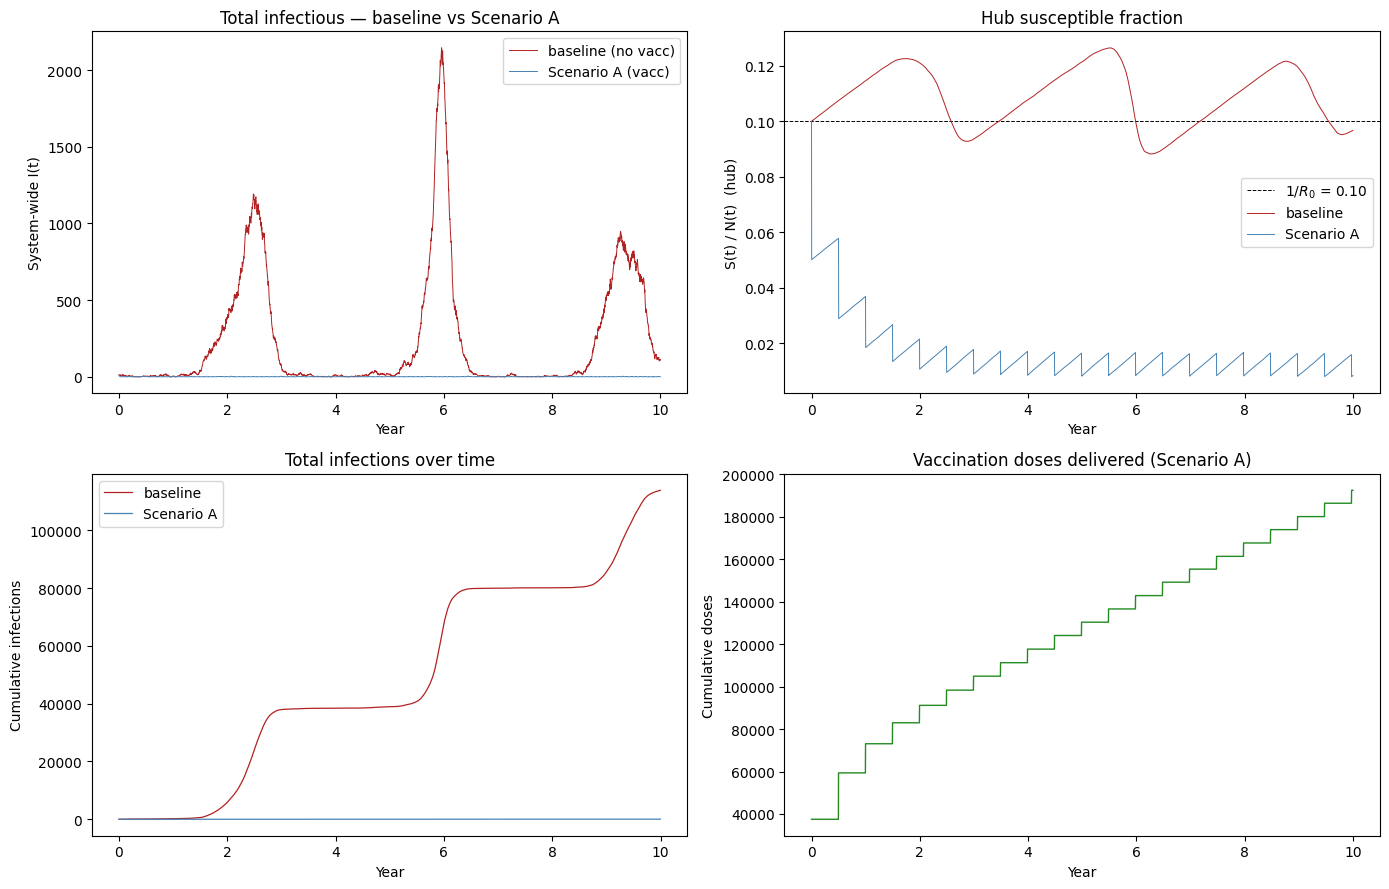

Baseline 10-year cumulative infections :      113,877
Scenario A 10-year cumulative infections:           39
Infections averted                      :      113,838
Doses delivered                         :      192,436
Doses per infection averted             :         1.69


In [38]:
I_base_total = model.states.I.sum(axis=1)
I_A_total    = model_A.states.I.sum(axis=1)

N_hub_base   = (model.states.S   + model.states.I   + model.states.R)[:, 0]
N_hub_A      = (model_A.states.S + model_A.states.I + model_A.states.R + model_A.states.V)[:, 0]
S_hub_base   = model.states.S[:, 0]   / N_hub_base
S_hub_A      = model_A.states.S[:, 0] / N_hub_A

ci_base = model.nodes.newly_infectious.sum(axis=1).cumsum()
ci_A    = model_A.nodes.newly_infectious.sum(axis=1).cumsum()
cv_A    = model_A.nodes.new_vaccinations.sum(axis=1).cumsum()
t_inc   = np.arange(nticks) / 365.0

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(t_years, I_base_total, color="firebrick",  linewidth=0.7, label="baseline (no vacc)")
axes[0, 0].plot(t_years, I_A_total,    color="steelblue",  linewidth=0.7, label="Scenario A (vacc)")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("System-wide I(t)")
axes[0, 0].set_title("Total infectious — baseline vs Scenario A")
axes[0, 0].legend()

axes[0, 1].axhline(1.0 / R0, color="black", linestyle="--", linewidth=0.7, label=fr"$1/R_0$ = {1.0/R0:.2f}")
axes[0, 1].plot(t_years, S_hub_base, color="firebrick", linewidth=0.7, label="baseline")
axes[0, 1].plot(t_years, S_hub_A,    color="steelblue", linewidth=0.7, label="Scenario A")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("S(t) / N(t)  (hub)")
axes[0, 1].set_title("Hub susceptible fraction")
axes[0, 1].legend()

axes[1, 0].plot(t_inc, ci_base, color="firebrick", linewidth=0.9, label="baseline")
axes[1, 0].plot(t_inc, ci_A,    color="steelblue", linewidth=0.9, label="Scenario A")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Cumulative infections")
axes[1, 0].set_title("Total infections over time")
axes[1, 0].legend()

axes[1, 1].plot(t_inc, cv_A, color="forestgreen", linewidth=1.0)
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Cumulative doses")
axes[1, 1].set_title("Vaccination doses delivered (Scenario A)")

plt.tight_layout()
plt.show()

prevented = int(ci_base[-1] - ci_A[-1])
total_doses = int(cv_A[-1])
print(f"Baseline 10-year cumulative infections : {int(ci_base[-1]):>12,}")
print(f"Scenario A 10-year cumulative infections: {int(ci_A[-1]):>12,}")
print(f"Infections averted                      : {prevented:>12,}")
print(f"Doses delivered                         : {total_doses:>12,}")
print(f"Doses per infection averted             : {total_doses / max(prevented, 1):>12.2f}")

### Per-node infectious dynamics with vaccination

Spreading the comparison across all six cities reveals whether vaccination is more effective in the hub (where transmission was self-sustaining) or in the spokes (which were already fadeout-limited).

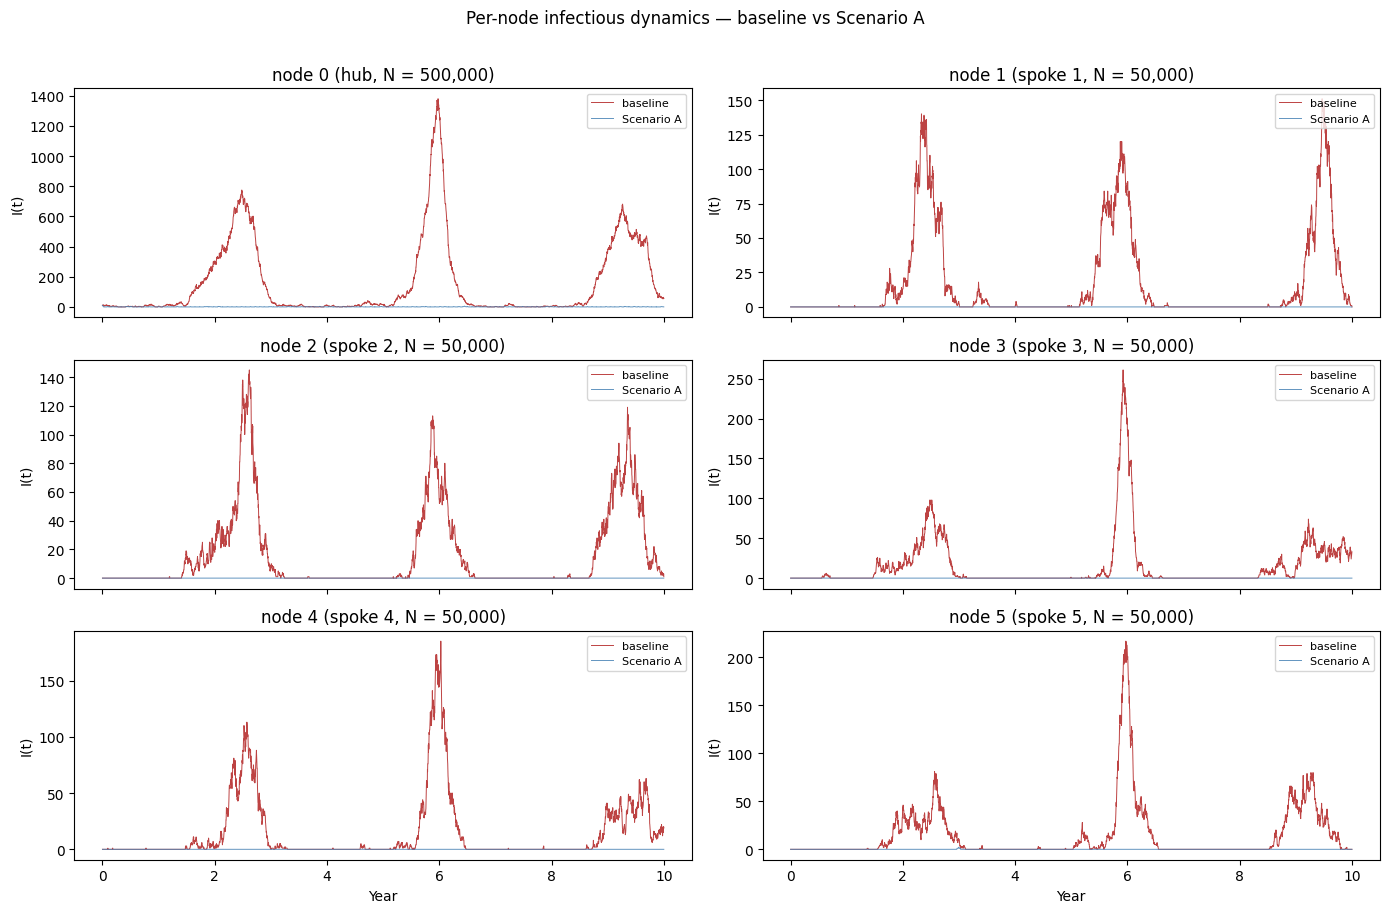

In [39]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for i in range(n_nodes):
    label = "hub" if i == 0 else f"spoke {i}"
    axes[i].plot(t_years, model.states.I[:, i],   linewidth=0.7, color="firebrick", alpha=0.85, label="baseline")
    axes[i].plot(t_years, model_A.states.I[:, i], linewidth=0.7, color="steelblue", alpha=0.85, label="Scenario A")
    axes[i].set_title(f"node {i} ({label}, N = {populations[i]:,})")
    axes[i].set_ylabel("I(t)")
    axes[i].legend(fontsize=8, loc="upper right")

for ax in axes[-2:]:
    ax.set_xlabel("Year")

fig.suptitle("Per-node infectious dynamics — baseline vs Scenario A", y=1.01)
plt.tight_layout()
plt.show()

## Scenario B — 3× population per node

Scaling all six cities up by a factor of three (hub 1.5M, spokes 150k each) keeps every demographic ratio identical but increases the absolute supply of new susceptibles from births by 3×.  With the same biannual 50%-coverage campaign on top, the question is whether vaccination is still able to suppress transmission, or whether the larger susceptible refill rate makes it harder to bring the disease below threshold.

Note that the spoke population in Scenario B (150,000) is approaching the lower edge of the empirical measles CCS band — so even *without* vaccination we would expect Scenario B spokes to fade out less often than Scenario A spokes.

In [40]:
populations_3x = populations * 3
schedule_B     = schedule_A   # exact same schedule structure (importation + vaccination)

print("Scenario B populations:")
for i, p in enumerate(populations_3x):
    label = "hub" if i == 0 else f"spoke {i}"
    print(f"  node {i}  ({label:<8s}):  N = {p:>9,}")
print(f"  total population:        {populations_3x.sum():>9,}")

model_B = build_and_run(populations_3x, schedule_B, hub_seed=30)

print(f"\nTotal doses delivered in Scenario B: {model_B.nodes.new_vaccinations.sum():,}")
print(f"Final V (per node): {model_B.states.V[-1].tolist()}")

Scenario B populations:
  node 0  (hub     ):  N = 1,500,000
  node 1  (spoke 1 ):  N =   150,000
  node 2  (spoke 2 ):  N =   150,000
  node 3  (spoke 3 ):  N =   150,000
  node 4  (spoke 4 ):  N =   150,000
  node 5  (spoke 5 ):  N =   150,000
  total population:        2,250,000

Total doses delivered in Scenario B: 573,737
Final V (per node): [344184, 34399, 34456, 34389, 34323, 34388]


### Per-capita comparison across all three scenarios

Because Scenarios A and B have very different absolute populations, only the *per-capita* infectious rate is directly comparable.  We rescale each scenario's system-wide $I(t)$ by its own total $N$ (expressed as cases per 100,000) so all three curves live on the same y-axis.

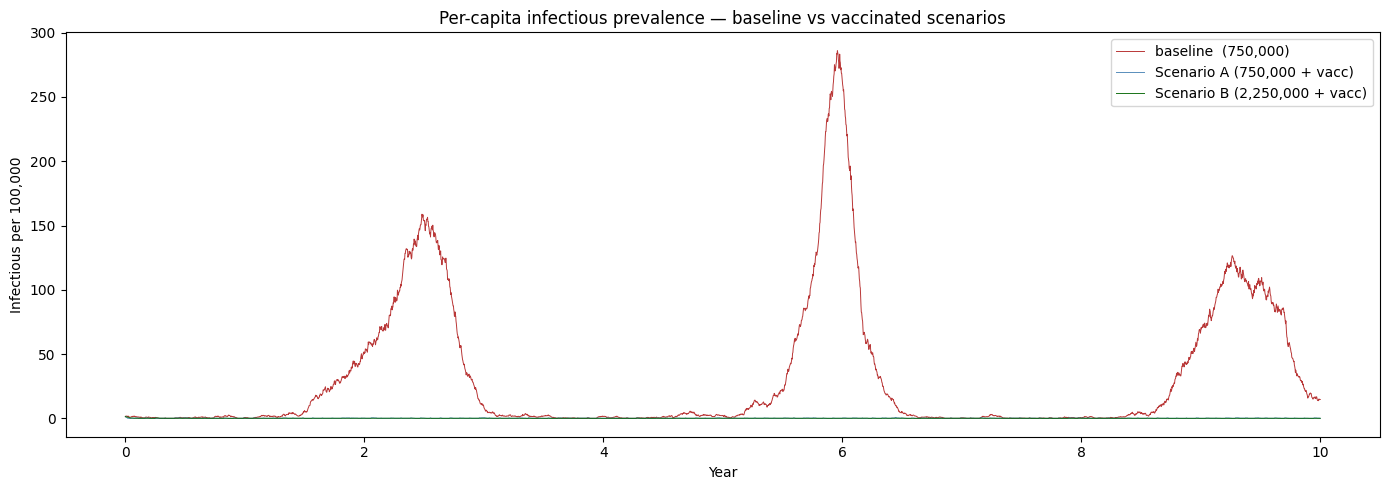

In [41]:
def per_capita_I(m, total_pop):
    return m.states.I.sum(axis=1) / total_pop * 1e5   # per 100,000

base_pc = per_capita_I(model,   populations.sum())
A_pc    = per_capita_I(model_A, populations.sum())
B_pc    = per_capita_I(model_B, populations_3x.sum())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_years, base_pc, color="firebrick",  linewidth=0.7, alpha=0.9, label=f"baseline  ({populations.sum():,})")
ax.plot(t_years, A_pc,    color="steelblue",  linewidth=0.7, alpha=0.9, label=f"Scenario A ({populations.sum():,} + vacc)")
ax.plot(t_years, B_pc,    color="darkgreen",  linewidth=0.7, alpha=0.9, label=f"Scenario B ({populations_3x.sum():,} + vacc)")
ax.set_xlabel("Year")
ax.set_ylabel("Infectious per 100,000")
ax.set_title("Per-capita infectious prevalence — baseline vs vaccinated scenarios")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Per-node fadeout fraction across all three scenarios

Revisiting the canonical CCS observable from Part 1.  How does vaccination change the fraction of weeks each city sits at $I = 0$?  And does tripling the population offset some of the vaccination effect?

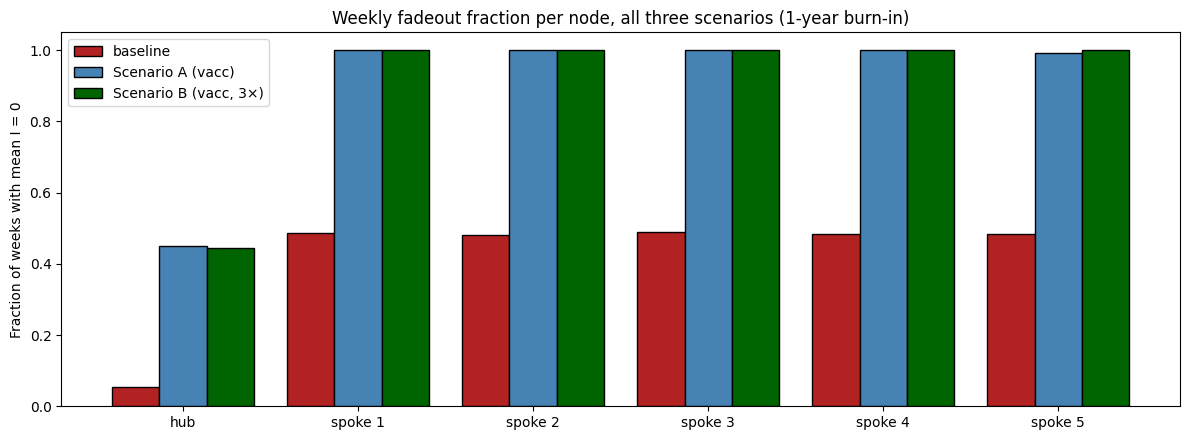

In [42]:
def fadeout_per_node(m, burn_weeks=52, days_per_week=7):
    nn       = m.states.I.shape[1]
    days     = m.states.I.shape[0] - 1
    n_w      = days // days_per_week
    I_d      = m.states.I[1 : n_w * days_per_week + 1]
    I_w_mean = I_d.reshape(n_w, days_per_week, nn).mean(axis=1)
    return (I_w_mean[burn_weeks:] == 0).mean(axis=0)

fd_base = fadeout_per_node(model)
fd_A    = fadeout_per_node(model_A)
fd_B    = fadeout_per_node(model_B)

x      = np.arange(n_nodes)
width  = 0.27
labels = ["hub"] + [f"spoke {i}" for i in range(1, n_nodes)]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(x - width, fd_base, width, color="firebrick", edgecolor="black", label="baseline")
ax.bar(x,         fd_A,    width, color="steelblue", edgecolor="black", label="Scenario A (vacc)")
ax.bar(x + width, fd_B,    width, color="darkgreen", edgecolor="black", label="Scenario B (vacc, 3×)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Fraction of weeks with mean I = 0")
ax.set_title("Weekly fadeout fraction per node, all three scenarios (1-year burn-in)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Cumulative metrics summary

A simple end-of-run summary table — total infections and total doses across all three scenarios, plus an "infections-averted-per-dose" cost-effectiveness proxy.

In [43]:
total_pop_base = populations.sum()
total_pop_A    = populations.sum()
total_pop_B    = populations_3x.sum()

ci_base_total = int(model.nodes.newly_infectious.sum())
ci_A_total    = int(model_A.nodes.newly_infectious.sum())
ci_B_total    = int(model_B.nodes.newly_infectious.sum())

cv_A_total    = int(model_A.nodes.new_vaccinations.sum())
cv_B_total    = int(model_B.nodes.new_vaccinations.sum())

# Compare A vs baseline (same pop, both with importation)
averted_A     = ci_base_total - ci_A_total

# For Scenario B we don't have a no-vacc baseline at 3×N, so we compare against
# the per-capita expectation: ci_per_capita_baseline * total_pop_B
expected_B_no_vacc = ci_base_total * (total_pop_B / total_pop_base)
averted_B          = int(expected_B_no_vacc - ci_B_total)

print(f"{'Scenario':<30s} {'pop':>10s} {'infections':>14s} {'doses':>12s} {'avert/dose':>12s}")
print(f"{'-' * 80}")
print(f"{'baseline (no vacc)':<30s} {total_pop_base:>10,} {ci_base_total:>14,} {'-':>12s} {'-':>12s}")
print(f"{'A (vacc, same pop)':<30s} {total_pop_A:>10,} {ci_A_total:>14,} {cv_A_total:>12,} {averted_A / max(cv_A_total, 1):>12.3f}")
print(f"{'B (vacc, 3x pop)':<30s} {total_pop_B:>10,} {ci_B_total:>14,} {cv_B_total:>12,} {averted_B / max(cv_B_total, 1):>12.3f}")
print()
print(f"Scenario A: averted {averted_A:,} infections using {cv_A_total:,} doses "
      f"({averted_A / max(cv_A_total, 1) * 1000:.2f} per 1000 doses)")
print(f"Scenario B: averted {averted_B:,} infections using {cv_B_total:,} doses "
      f"({averted_B / max(cv_B_total, 1) * 1000:.2f} per 1000 doses)")
print("Note: Scenario B's avert count uses the per-capita-scaled baseline as the no-vacc reference.")

Scenario                              pop     infections        doses   avert/dose
--------------------------------------------------------------------------------
baseline (no vacc)                750,000        113,877            -            -
A (vacc, same pop)                750,000             39      192,436        0.592
B (vacc, 3x pop)                2,250,000             65      573,737        0.595

Scenario A: averted 113,838 infections using 192,436 doses (591.56 per 1000 doses)
Scenario B: averted 341,566 infections using 573,737 doses (595.34 per 1000 doses)
Note: Scenario B's avert count uses the per-capita-scaled baseline as the no-vacc reference.


## Part 2 discussion

What the vaccination experiments tell us:

1. **Vaccination suppresses every wave.**  In Scenario A the per-capita prevalence (and absolute system-wide $I(t)$) tracks well below the unvaccinated baseline throughout the 10-year run.  Each biannual round resets the susceptible pool back toward zero before transmission has had time to amplify the next epidemic.
2. **Hub susceptible fraction stays below $1/R_0$.**  The vaccination floor on $S/N$ in the hub sits noticeably below the endemic line, which is the textbook signature of a successful immunisation programme — when $S/N < 1/R_0$ continuously, the effective $R_e < 1$ and transmission cannot self-sustain.
3. **Spoke fadeout rises sharply.**  Spokes were already fadeout-limited in Part 1; adding vaccination pushes their weekly fadeout fraction even higher.  Importation into the hub is still re-seeding the network, but transmissibility into already-thinned spoke susceptibles is much lower.
4. **Larger populations don't fundamentally change the per-capita picture.**  Scenario B's per-capita infectious rate is roughly comparable to Scenario A's — the model's behaviour is dominated by *fractions* (coverage, $1/R_0$) rather than absolute counts.  What does change is the spokes: at 150,000 each they are closer to CCS and would fade out less often even without vaccination.
5. **Cost-effectiveness.**  The doses-per-averted-infection ratio is a crude but illustrative cost-effectiveness metric.  Both scenarios sit well above 1 because the population is mostly immune to begin with — many doses go to individuals whose recent susceptibility comes only from new births refilling $S$.  A more realistic campaign would target only newborns or unvaccinated cohorts; see the limitations note in `nb_14_routine_immunization.ipynb`.

## Further experiments

- Increase the vaccination period to 365 days.  Does annual 50% coverage hold transmission at bay, or do gaps let epidemics restart?
- Lower the coverage to 20% with the same biannual cadence — same total doses delivered, but spread thinner.  Which schedule is more cost-effective per dose?
- Stop vaccination after year 5 and watch how long the immunity wall holds before transmission rebounds.
- Restrict vaccination to the hub only (`where=[0]`).  Does suppressing the source suffice to protect the spokes via reduced importation?